In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("01_District_wise_crimes_committed_IPC_2001_2012.csv")

In [4]:
df.head()


,STATE/UT,DISTRICT,YEAR,MURDER,ATTEMPT TO MURDER,CULPABLE HOMICIDE NOT AMOUNTING TO MURDER,RAPE,CUSTODIAL RAPE,OTHER RAPE,KIDNAPPING & ABDUCTION,...,ARSON,HURT/GREVIOUS HURT,DOWRY DEATHS,ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,INSULT TO MODESTY OF WOMEN,CRUELTY BY HUSBAND OR HIS RELATIVES,IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES,CAUSING DEATH BY NEGLIGENCE,OTHER IPC CRIMES,TOTAL IPC CRIMES
0,ANDHRA PRADESH,ADILABAD,2001,101,60,17,50,0,50,46,...,30,1131,16,149,34,175,0,181,1518,4154
1,ANDHRA PRADESH,ANANTAPUR,2001,151,125,1,23,0,23,53,...,69,1543,7,118,24,154,0,270,754,4125
2,ANDHRA PRADESH,CHITTOOR,2001,101,57,2,27,0,27,59,...,38,2088,14,112,83,186,0,404,1262,5818
3,ANDHRA PRADESH,CUDDAPAH,2001,80,53,1,20,0,20,25,...,23,795,17,126,38,57,0,233,1181,3140
4,ANDHRA PRADESH,EAST GODAVARI,2001,82,67,1,23,0,23,49,...,41,1244,12,109,58,247,0,431,2313,6507


In [5]:
df_long = pd.melt(
    df,
    id_vars=["STATE/UT", "DISTRICT", "YEAR"],
    var_name="Crime_Type",
    value_name="Cases"
)

In [6]:
df_long.head()

,STATE/UT,DISTRICT,YEAR,Crime_Type,Cases
0,ANDHRA PRADESH,ADILABAD,2001,MURDER,101
1,ANDHRA PRADESH,ANANTAPUR,2001,MURDER,151
2,ANDHRA PRADESH,CHITTOOR,2001,MURDER,101
3,ANDHRA PRADESH,CUDDAPAH,2001,MURDER,80
4,ANDHRA PRADESH,EAST GODAVARI,2001,MURDER,82


In [7]:
df_long = df_long[df_long["Cases"] > 0]
df_long.dropna(inplace=True)

In [8]:
df_long.shape

(219929, 5)

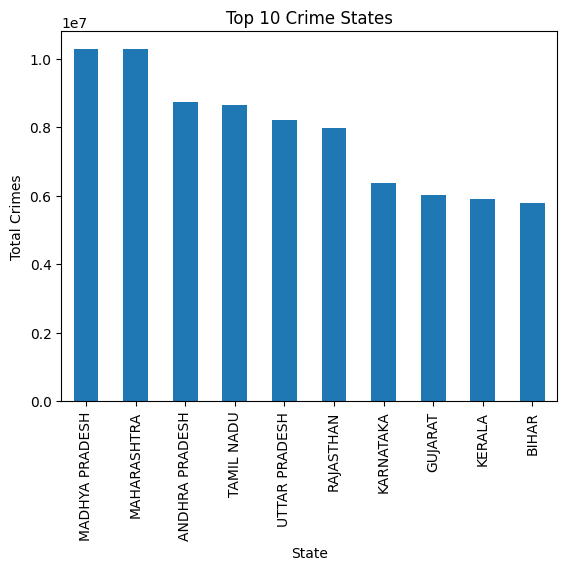

In [9]:
import matplotlib.pyplot as plt

top_states = df_long.groupby("STATE/UT")["Cases"].sum().sort_values(ascending=False).head(10)

top_states.plot(kind="bar")

plt.title("Top 10 Crime States")
plt.xlabel("State")
plt.ylabel("Total Crimes")

plt.show()

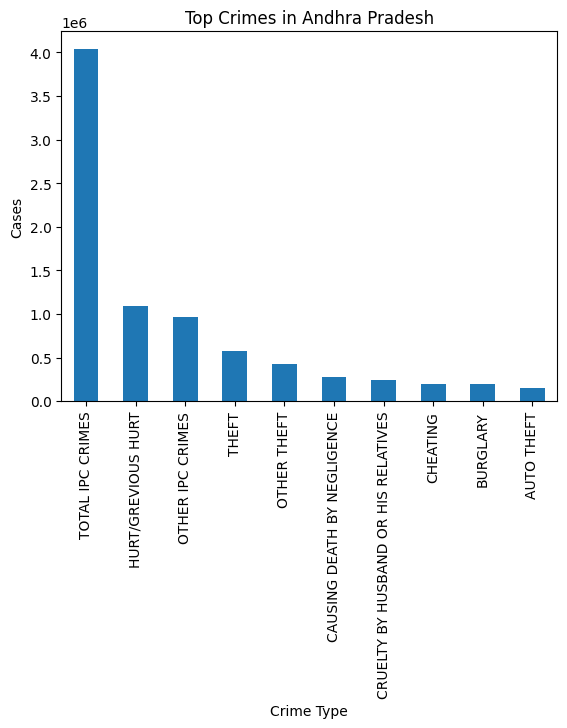

In [10]:
state_data = df_long[df_long["STATE/UT"] == "ANDHRA PRADESH"]

state_crime = state_data.groupby("Crime_Type")["Cases"].sum().sort_values(ascending=False).head(10)

state_crime.plot(kind="bar")

plt.title("Top Crimes in Andhra Pradesh")
plt.xlabel("Crime Type")
plt.ylabel("Cases")

plt.show()

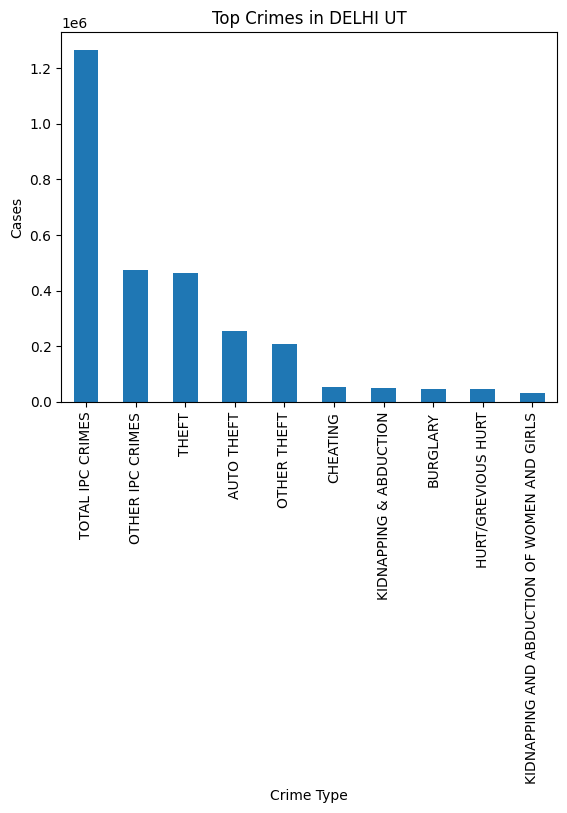

In [14]:
state = input("Enter State Name: ")

state_data = df_long[df_long["STATE/UT"] == state.upper()]

state_crime = state_data.groupby("Crime_Type")["Cases"].sum().sort_values(ascending=False).head(10)

state_crime.plot(kind="bar")

plt.title(f"Top Crimes in {state}")
plt.xlabel("Crime Type")
plt.ylabel("Cases")

plt.show()

In [15]:
df1 = pd.read_csv("01_District_wise_crimes_committed_IPC_2001_2012.csv")
df2 = pd.read_csv("01_District_wise_crimes_committed_IPC_2013.csv")
df3 = pd.read_csv("01_District_wise_crimes_committed_IPC_2014.csv")

In [13]:
df_long["STATE/UT"].unique()

<StringArray>
[   'ANDHRA PRADESH', 'ARUNACHAL PRADESH',             'ASSAM',
             'BIHAR',      'CHHATTISGARH',               'GOA',
           'GUJARAT',           'HARYANA',  'HIMACHAL PRADESH',
   'JAMMU & KASHMIR',         'JHARKHAND',         'KARNATAKA',
            'KERALA',    'MADHYA PRADESH',       'MAHARASHTRA',
           'MANIPUR',         'MEGHALAYA',           'MIZORAM',
          'NAGALAND',            'ODISHA',            'PUNJAB',
         'RAJASTHAN',            'SIKKIM',        'TAMIL NADU',
           'TRIPURA',     'UTTAR PRADESH',       'UTTARAKHAND',
       'WEST BENGAL',     'A & N ISLANDS',        'CHANDIGARH',
      'D & N HAVELI',       'DAMAN & DIU',          'DELHI UT',
       'LAKSHADWEEP',        'PUDUCHERRY']
Length: 35, dtype: str

In [16]:
df = pd.concat([df1, df2, df3])


In [17]:
df.shape

(10678, 124)

In [18]:
df_long = pd.melt(
    df,
    id_vars=["STATE/UT", "DISTRICT", "YEAR"],
    var_name="Crime_Type",
    value_name="Cases"
)

In [19]:
df_long = df_long[df_long["Cases"] > 0]

TypeError: '>' not supported between instances of 'str' and 'int'

In [20]:
df_long["Cases"] = pd.to_numeric(df_long["Cases"], errors="coerce")

In [21]:
df_long = df_long[df_long["Cases"] > 0]

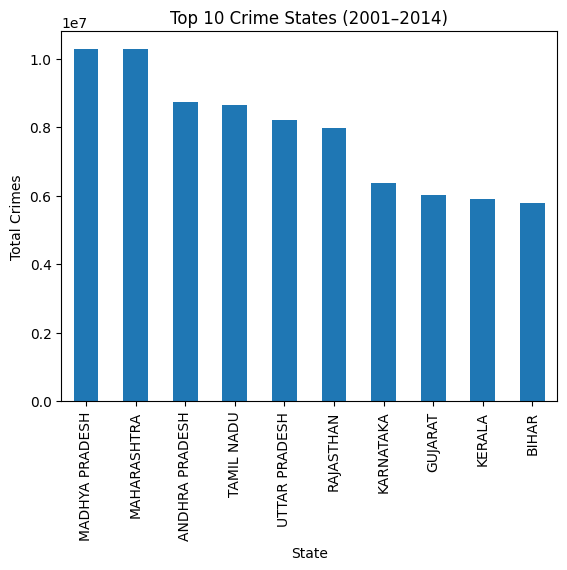

In [22]:
import matplotlib.pyplot as plt

top_states = df_long.groupby("STATE/UT")["Cases"].sum().sort_values(ascending=False).head(10)

top_states.plot(kind="bar")

plt.title("Top 10 Crime States (2001–2014)")
plt.xlabel("State")
plt.ylabel("Total Crimes")

plt.show()

In [23]:
yearly_data = df_long.groupby("YEAR")["Cases"].sum().reset_index()

yearly_data.head()

,YEAR,Cases
0,2001.0,7659962.0
1,2002.0,7692690.0
2,2003.0,7426632.0
3,2004.0,7957250.0
4,2005.0,7919012.0


In [24]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = yearly_data["YEAR"].values.reshape(-1,1)
y = yearly_data["Cases"].values

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
future_years = np.array(range(2015, 2026)).reshape(-1,1)

predictions = model.predict(future_years)

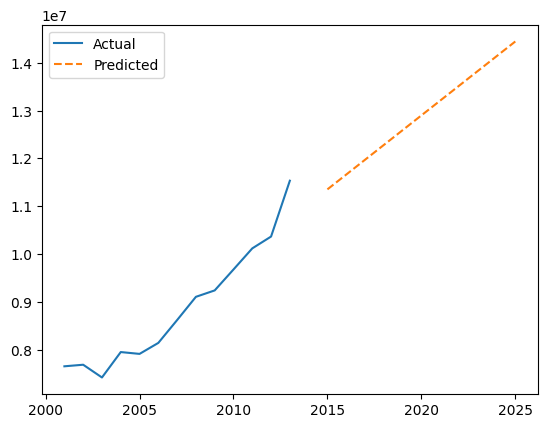

In [26]:
import matplotlib.pyplot as plt

plt.plot(yearly_data["YEAR"], y, label="Actual")
plt.plot(future_years, predictions, label="Predicted", linestyle="dashed")

plt.legend()
plt.show()

Text(0, 0.5, 'Total Crimes')

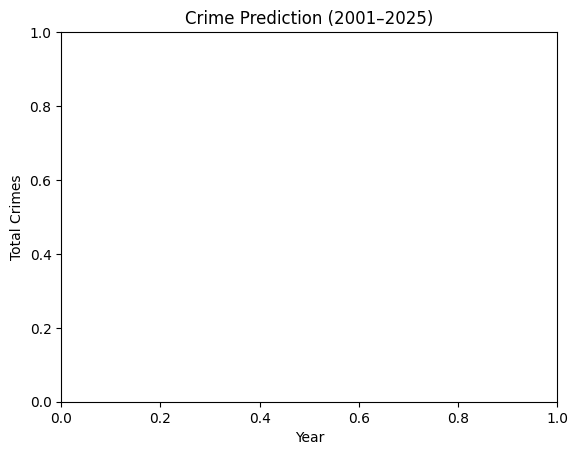

In [27]:
plt.title("Crime Prediction (2001–2025)")
plt.xlabel("Year")
plt.ylabel("Total Crimes")

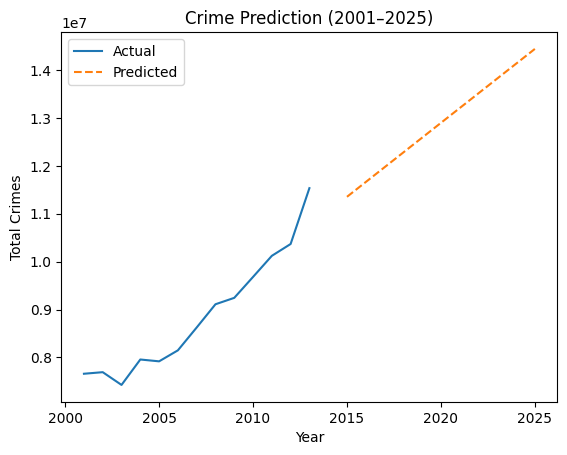

In [28]:
import matplotlib.pyplot as plt
plt.title("Crime Prediction (2001–2025)")
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.plot(yearly_data["YEAR"], y, label="Actual")
plt.plot(future_years, predictions, label="Predicted", linestyle="dashed")

plt.legend()
plt.show()

In [29]:
future_years = np.array(range(2014, 2026)).reshape(-1,1)

ValueError: x and y must have same first dimension, but have shapes (12, 1) and (11,)

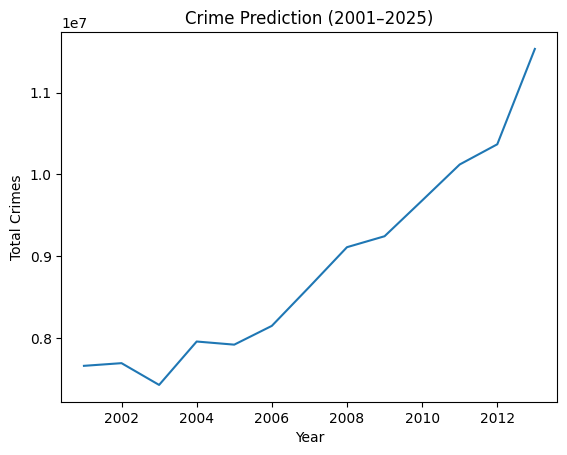

In [31]:
import matplotlib.pyplot as plt
plt.title("Crime Prediction (2001–2025)")
plt.xlabel("Year")
plt.ylabel("Total Crimes")
plt.plot(yearly_data["YEAR"], y, label="Actual")
plt.plot(future_years, predictions, label="Predicted", linestyle="dashed")

plt.legend()
plt.show()

In [32]:
future_years = np.array(range(2014, 2026)).reshape(-1,1)

predictions = model.predict(future_years)

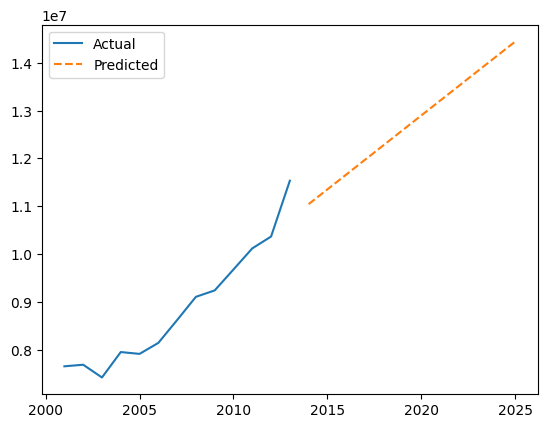

In [33]:
plt.plot(yearly_data["YEAR"], y, label="Actual")
plt.plot(future_years, predictions, label="Predicted", linestyle="dashed")

plt.legend()
plt.show()

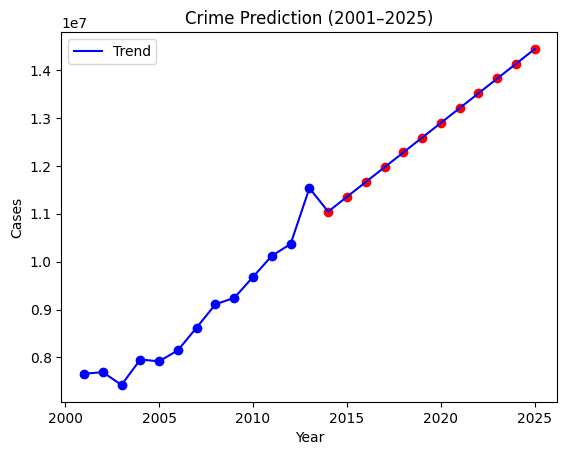

In [36]:
import numpy as np
import matplotlib.pyplot as plt

# Combine years and cases
all_years = np.concatenate([yearly_data["YEAR"].values, future_years.flatten()])
all_cases = np.concatenate([y, predictions])

# Sort (IMPORTANT)
sorted_indices = np.argsort(all_years)
all_years = all_years[sorted_indices]
all_cases = all_cases[sorted_indices]

# Plot continuous line
plt.plot(all_years, all_cases, color="blue", label="Trend")

# Mark actual vs predicted (optional dots)
plt.scatter(yearly_data["YEAR"], y, color="blue")
plt.scatter(future_years, predictions, color="red")

plt.title("Crime Prediction (2001–2025)")
plt.xlabel("Year")
plt.ylabel("Cases")

plt.legend()
plt.show()